In [13]:
%matplotlib ipympl
from collections import defaultdict

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import pandas.plotting._matplotlib.converter as pdtc


In [2]:
geo311 = gpd.read_file("data/311_2026.geojson")

In [3]:
geo311_agg = geo311.pivot_table(values='Additional Details', index='Borough', columns=['Problem Detail (formerly Descriptor)'], aggfunc='count').T
geo311_top5_complaints = geo311_agg.sum(axis=1).sort_values(ascending=False).index[:5]
geo311_top5 = geo311[geo311['Problem Detail (formerly Descriptor)'].isin(geo311_top5_complaints)]

In [4]:
cdict = dict(zip(geo311['Borough'].unique(), ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']))

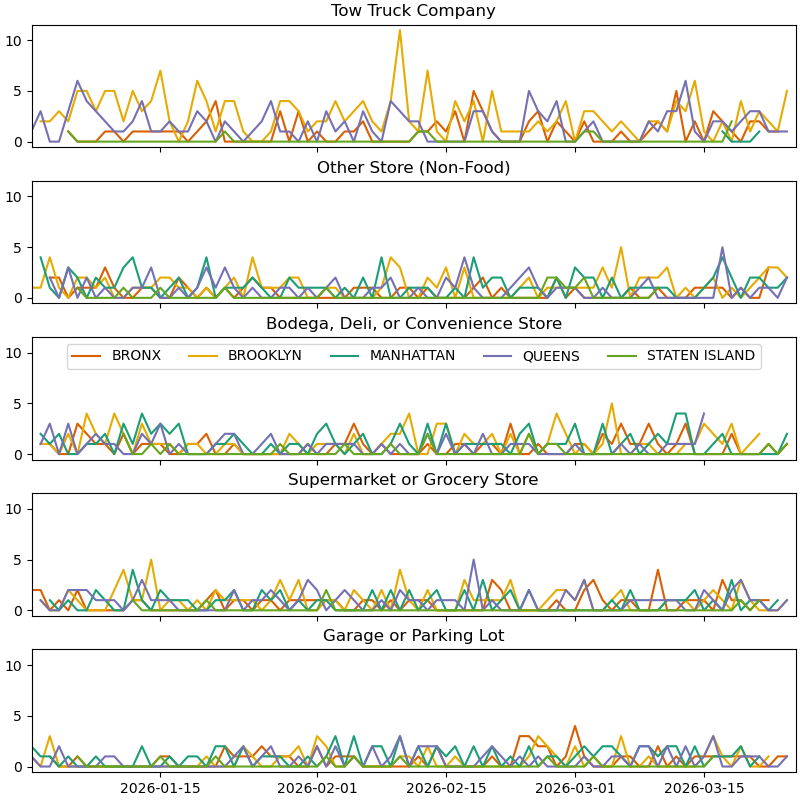

In [5]:
fig, axd = plt.subplot_mosaic([[g] for g in geo311_top5_complaints], 
                              sharex=True, sharey=True, figsize=(8, 8), layout='compressed')

for name, gdfsub in geo311_top5.groupby(['Problem Detail (formerly Descriptor)']):
    axn = name[0]
    axd[axn].set_title(axn)
    for (b, gdfts) in gdfsub.groupby(['Borough']):
        ts = gdfts.groupby(pd.Grouper(key='Created Date', freq='D'))['Problem Detail (formerly Descriptor)'].count()
        l, = axd[axn].plot(ts.index, ts.values, label=b[0], color=cdict[b[0]])

axd[axn].set(xlim=(geo311_top5['Created Date'].min(),geo311_top5['Created Date'].max()))
handles, labels = axd[axn].get_legend_handles_labels()
axd[geo311_top5_complaints[2]].legend(handles, labels, ncol=5, loc='upper center')
plt.show()


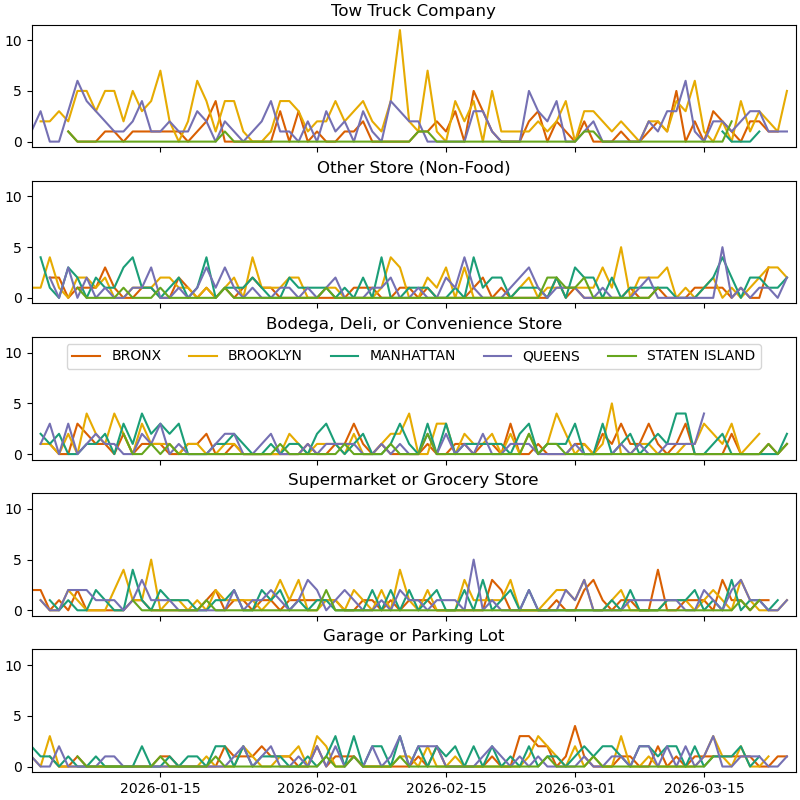

In [44]:
fig, axd = plt.subplot_mosaic([[g, f'map_{g}'] for g in geo311_top5_complaints], figsize=(10,5), layout='compressed', width_ratios=[2,1])

fig, axd = plt.subplot_mosaic([[g] for g in geo311_top5_complaints], 
                              sharex=True, sharey=True, figsize=(8, 8), layout='compressed')

lines = {b:[] for b in geo311_top5['Borough'].unique()}

for name, gdfsub in geo311_top5.groupby(['Problem Detail (formerly Descriptor)']):
    axn = name[0]
    axd[axn].set_title(axn)  
    for (b, gdfts) in gdfsub.groupby(['Borough']):
        ts = gdfts.groupby(pd.Grouper(key='Created Date', freq='D'))['Problem Detail (formerly Descriptor)'].count()
        l, = axd[axn].plot(ts.index, ts.values, label=b[0], color=cdict[b[0]])
        lines[b[0]].append(l)

axd[axn].set(xlim=(geo311_top5['Created Date'].min(),geo311_top5['Created Date'].max()))
handles, labels = axd[axn].get_legend_handles_labels()
leg = axd[geo311_top5_complaints[2]].legend(handles, labels, ncol=5, loc='upper center')

pickradius = 5  

map_legend_to_ax = {}
for label, legend_line in zip(labels, leg.get_lines()):
    legend_line.set_picker(pickradius)  # Enable picking on the legend line.
    map_legend_to_ax[legend_line] = lines[label]

def on_pick(event):
    # On the pick event, find the original line corresponding to the legend
    # proxy line, and toggle its visibility.
    legend_line = event.artist

    # Do nothing if the source of the event is not a legend line.
    if legend_line not in map_legend_to_ax:
        return

    ax_lines = map_legend_to_ax[legend_line]
    visible = not all(ax_line.get_visible() for ax_line in ax_lines)
    [ax_line.set_visible(visible) for ax_line in ax_lines]
    # Change the alpha on the line in the legend, so we can see what lines
    # have been toggled.
    legend_line.set_alpha(1.0 if visible else 0.2)
    fig.canvas.draw()


fig.canvas.mpl_connect('pick_event', on_pick)

# Works even if the legend is draggable. This is independent from picking legend lines.
leg.set_draggable(True)

plt.show()

In [42]:
lines

defaultdict(list,
            {('BRONX',): [<matplotlib.lines.Line2D at 0x148916e3230>,
             ('BROOKLYN',): [<matplotlib.lines.Line2D at 0x148916e3b60>,
             ('MANHATTAN',): [<matplotlib.lines.Line2D at 0x148916e3cb0>,
             ('QUEENS',): [<matplotlib.lines.Line2D at 0x148916e3e00>,
             ('STATEN ISLAND',): [<matplotlib.lines.Line2D at 0x14891764050>,
             'BRONX': [],
             'BROOKLYN': [],
             'MANHATTAN': [],
             'QUEENS': [],
             'STATEN ISLAND': []})